In [2]:
%run CleanData.ipynb

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
# ==================== IMPORTS ====================
import pandas as pd 
import kagglehub as kh
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# ==================== DOWNLOAD & LOAD DATA ====================
# Download dataset from KaggleHub
path = kh.dataset_download("shayanfazeli/heartbeat")

def load_data(path):
    mitbih_train = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
    mitbih_test = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)
    ptbdb_normal = pd.read_csv(os.path.join(path, "ptbdb_normal.csv"), header=None)
    ptbdb_abnormal = pd.read_csv(os.path.join(path, "ptbdb_abnormal.csv"), header=None)
    return mitbih_train, mitbih_test, ptbdb_normal, ptbdb_abnormal

mitbih_train, mitbih_test, ptbdb_normal, ptbdb_abnormal = load_data(path)

# ==================== ASSIGN LABELS FOR PTBDB ====================
def replace_label_column(data, label):
    data.iloc[:, -1] = label
    return data

ptbdb_normal = replace_label_column(ptbdb_normal, 6)  # normal
ptbdb_abnormal = replace_label_column(ptbdb_abnormal, 7)  # abnormal

ptbdb_all = pd.concat([ptbdb_normal, ptbdb_abnormal], ignore_index=True)

# ==================== SPLIT PTBDB ONLY ====================
X_ptbdb_train, X_ptbdb_test, y_ptbdb_train, y_ptbdb_test = train_test_split(
    ptbdb_all.iloc[:, :-1], ptbdb_all.iloc[:, -1], test_size=0.2, random_state=42
)

# ==================== COMBINE WITH MITBIH ====================
X_train_df = pd.concat([X_ptbdb_train, mitbih_train.iloc[:, :-1]], ignore_index=True)
y_train = pd.concat([y_ptbdb_train, mitbih_train.iloc[:, -1]], ignore_index=True)

X_test_df = pd.concat([X_ptbdb_test, mitbih_test.iloc[:, :-1]], ignore_index=True)
y_test = pd.concat([y_ptbdb_test, mitbih_test.iloc[:, -1]], ignore_index=True)

# ==================== LABEL REMAPPING ====================
# Merge class 6 into 0 ("Normal"), rename 7 to 5 ("Abnormal")
y_train = y_train.astype(int).replace({6: 0, 7: 5}).reset_index(drop=True)
y_test = y_test.astype(int).replace({6: 0, 7: 5}).reset_index(drop=True)

# ==================== DROP LOW-INFORMATION COLUMNS ====================
def drop_almost_zero_columns(X, threshold=0.8):
    zero_fraction = (X == 0).sum() / len(X)
    drop_cols = zero_fraction[zero_fraction >= threshold].index
    return X.drop(columns=drop_cols)

X_train_df = drop_almost_zero_columns(X_train_df)
X_test_df = drop_almost_zero_columns(X_test_df)

# ==================== CONVERT TO NUMPY ====================
X_train = X_train_df.values
X_test = X_test_df.values
y_train = y_train.values
y_test = y_test.values

# ==================== SPLIT TRAIN -> TRAIN + VALIDATION ====================
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# ==================== NORMALIZATION ====================
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==================== RESHAPE FOR GRU/CNN INPUT ====================
# Final shape: (samples, timesteps, 1 feature)
X_train_final = X_train_final.reshape((X_train_final.shape[0], X_train_final.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ==================== ONE-HOT ENCODE LABELS ====================
# Infer number of classes from all combined y
all_labels = np.concatenate([y_train, y_test])
unique_classes = np.unique(all_labels)
num_classes = len(unique_classes)

y_train_cat = to_categorical(y_train_final, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# ==================== CLASS WEIGHTS (Manually Defined) ====================
class_weights = {
    0: 1.0,   # Normal
    1: 4.0,   # Supraventricular
    2: 1.5,   # Ventricular
    3: 5.0,   # Fusion
    4: 1.0,   # Unknown
    5: 1.2    # Abnormal
}

# ==================== CONDITIONS ====================
conditions = {
    0: "Normal (N)",
    1: "Supraventricular premature (S)",
    2: "Premature ventricular contraction (V)",
    3: "Fusion of ventricular and normal beat (F)",
    4: "Unclassifiable beat (Q)",
    5: "Abnormal (A)"
}

In [ ]:
#reshape the train and test sets to 3D — which is required by GRUs ([samples, timesteps, features]).
# X_train, X_test, y_train, y_test = joblib.load("ecg_split_data.pkl")
X_train = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))
y_train = to_categorical(y_train, num_classes=6)
y_test = to_categorical(y_test, num_classes=6)
import numpy as np
np.bincount(np.argmax(y_train, axis=1))

array([75683,  2223,  5788,   641,  6431,  8429])

In [ ]:
# Convert from one-hot to int labels
y_train_int = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.21844403630934292), 1: np.float64(7.4370220422852), 2: np.float64(2.8563407049067036), 3: np.float64(25.79173166926677), 4: np.float64(2.570751049603483), 5: np.float64(1.9613833194922292)}


In [9]:
model = Sequential([
    GRU(64, input_shape=(X_train_final.shape[1], X_train_final.shape[2])),
    Dense(6, activation='softmax')
    
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)
# Optional: Add early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
# Train the model
history = model.fit(
    X_train_final, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)


Epoch 1/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 131s 52ms/step - accuracy: 0.7631 - loss: 1.2413 - val_accuracy: 0.8356 - val_loss: 0.5390
Epoch 2/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 127s 51ms/step - accuracy: 0.8531 - loss: 0.7184 - val_accuracy: 0.8784 - val_loss: 0.3952
Epoch 3/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 125s 50ms/step - accuracy: 0.8841 - loss: 0.5341 - val_accuracy: 0.9009 - val_loss: 0.3110
Epoch 4/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 132s 53ms/step - accuracy: 0.9100 - loss: 0.4317 - val_accuracy: 0.9149 - val_loss: 0.2858
Epoch 5/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 125s 51ms/step - accuracy: 0.9196 - loss: 0.3756 - val_accuracy: 0.9297 - val_loss: 0.2279
Epoch 6/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 131s 53ms/step - accuracy: 0.9284 - loss: 0.3380 - val_accuracy: 0.9377 - val_loss: 0.1985
Epoch 7/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 127s 51ms/step - accuracy: 0.9365 - loss: 0.2988 - val_accuracy: 0.9432 - val_loss: 0.1875
Epoch 8/10
2480/2480 ━━━━━━━━━━━━━━━━━━━━ 1010s 407ms/step - accuracy

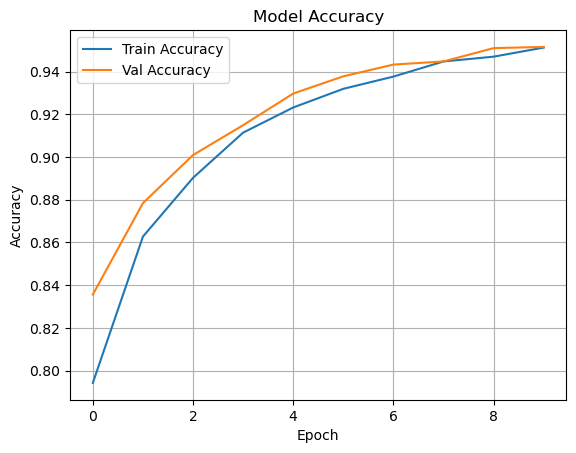

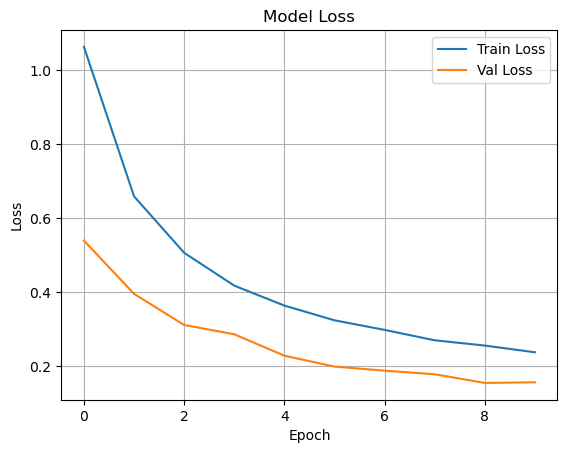

In [10]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


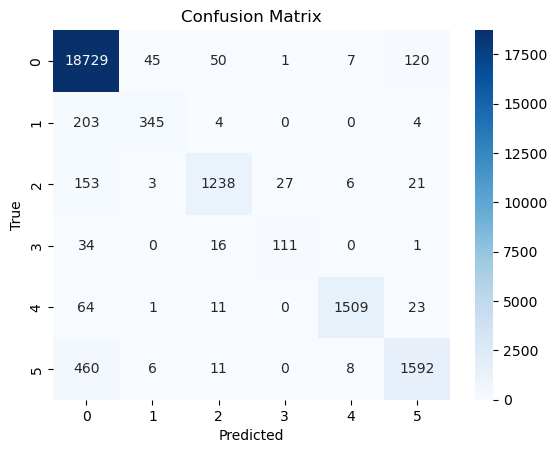

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     18952
           1       0.86      0.62      0.72       556
           2       0.93      0.85      0.89      1448
           3       0.80      0.69      0.74       162
           4       0.99      0.94      0.96      1608
           5       0.90      0.77      0.83      2077

    accuracy                           0.95     24803
   macro avg       0.91      0.81      0.85     24803
weighted avg       0.95      0.95      0.95     24803



In [12]:
# Predict classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification report
print(classification_report(y_true_classes, y_pred_classes))

C:\Users\hawra\AppData\Local\Temp\ipykernel_43952\155787283.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


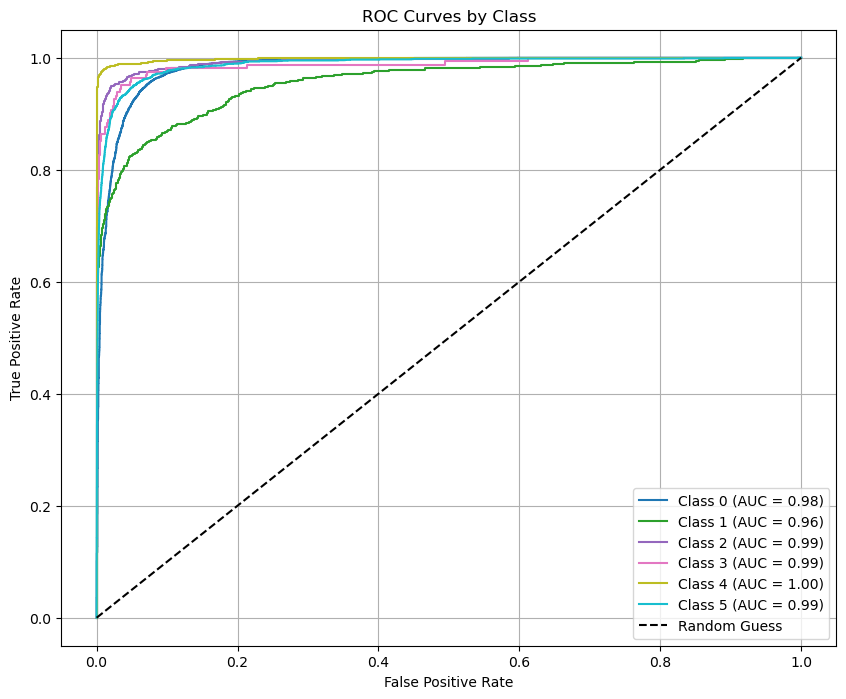

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Number of classes
num_classes = y_test_cat.shape[1]

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_cat[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', num_classes)

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})", color=colors(i))

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Class")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
